In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# %cd /content/drive/MyDrive/Dataset/25886_Kritika_Gupta_Assignment_2

/content/drive/MyDrive/Dataset/25886_Kritika_Gupta_Assignment_2


In [ ]:
import numpy as np
from glob import glob
from tqdm import tqdm
from skimage import io
from scipy import stats
import matplotlib.pyplot as plt
from skimage.transform import resize
from torch.utils.data import random_split
from torch.utils.data import Dataset, DataLoader

# PCA

In [4]:
'''
change FOLDER_PATH accordingly
'''
FOLDER_PATH = "../"
TRAIN_IMAGES_PATH = FOLDER_PATH + "train/images/"
PCA_COMPONENTS = [5, 10, 20, 50, 100]
VAR_THRESHOLD = 0.99

In [5]:
def load_image(file_path,size=None,flatten=False):
    '''
    loads image from the given file path and resizes it
    '''
    img = io.imread(file_path)
    if size:
      img = resize(img,size)
    img = np.array(img, dtype=np.float32)
    if flatten:
        img =img.flatten()
    return img

def PCA_numpy(X,k=2,var_threshold = None):
    '''
    performs PCA and return reconstructed image and
    if var_threshold is given then return
      number of components required to retain VAR_THRESHOLD
    else
      variance retained by number of compoments
    '''

    X_mean = np.mean(X,axis=0)
    X_centered = X - X_mean

    U,S,Vt = np.linalg.svd(X_centered,full_matrices=False)

    variance = (S**2) / (X.shape[0] - 1)
    variance_ratio = variance/np.sum(variance)
    cumulative_variance = np.cumsum(variance_ratio)

    if var_threshold:
        k = np.argmax(cumulative_variance >=var_threshold) +1

    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]

    X_reconstructed = U_k@np.diag(S_k)@Vt_k + X_mean
    X_reconstructed = np.clip(X_reconstructed, 0, 1)

    if var_threshold:
        return X_reconstructed, k
    else:
        return X_reconstructed, cumulative_variance[k]


def PCA_img_threshold(img,var_threshold = 0.9):
    '''
    perofrms pca on all channels of images for a given variance threshold
    '''

    if img.ndim == 2:
        return PCA_numpy(img,var_threshold=var_threshold)
    else:
        recon_image = []
        k_channels = []
        for c in range(img.shape[2]):
            recon_channel,k = PCA_numpy(img[:,:,c], var_threshold=var_threshold)
            recon_image.append(recon_channel)
            k_channels.append(k)
        return np.stack(recon_image,axis=2),k_channels

def PCA_img(img,n_components = 2):
    '''
    performs pca on all channels of images for a given number of components
    '''

    if img.ndim == 2:
        return PCA_numpy(img,k=n_components)
    else:
        recon_image = []
        var_channels = []
        for c in range(img.shape[2]):
            recon_channel,var = PCA_numpy(img[:,:,c], k=n_components)
            recon_image.append(recon_channel)
            var_channels.append(var)
        return np.stack(recon_image,axis=2),var_channels

def plot_pca(img,n_components=10):
    '''
    plot original image, reconstructed image and difference image
    image difference is exaggerated (by a multiplier of 10) to see the difference better
    '''
    recon_img,variance = PCA_img(img,n_components=n_components)
    print(variance)

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(img)

    plt.subplot(1,3,2)
    plt.imshow(recon_img)

    plt.subplot(1,3,3)
    plt.imshow((img-recon_img)*10)

    plt.tight_layout()
    plt.show()

In [6]:
## load images
pca_image_files = glob(TRAIN_IMAGES_PATH+"*.jpg")[:100]
for img_size in [(112,112),(64,64),(32,32)]:
  recon_error = []
  k_channels = []

  pca_image_dataset = [load_image(image_file,size=img_size) for image_file in pca_image_files]

  for img in tqdm(pca_image_dataset):
    recon_image,k = PCA_img_threshold(img,var_threshold=VAR_THRESHOLD)
    diff = img-recon_image
    recon_error.append(np.abs(diff).mean(axis=(0,1)))
    k_channels.append(k)

  k_channels = np.array(k_channels)
  recon_error = np.array(recon_error)

  print(img_size)
  print('\n')

  print("k_channels")
  print('Mode: ',stats.mode(k_channels,keepdims=True,axis=0).mode[0])
  print('Mean: ', np.mean(k_channels,axis=0))
  print('\n')

  print("Reconstruction error")
  print('Channel wise mean difference: ',recon_error.mean(axis=(0)))
  print('Mean difference: ' ,recon_error.mean())
  print('\n')

100%|██████████| 100/100 [00:01<00:00, 76.59it/s]


(112, 112)


k_channels
Mode:  [35 31 25]
Mean:  [31.08 30.65 30.05]


Reconstruction error
Channel wise mean difference:  [0.01406278 0.01370326 0.01406519]
Mean difference:  0.013943742




100%|██████████| 100/100 [00:01<00:00, 65.53it/s]


(64, 64)


k_channels
Mode:  [18 19 13]
Mean:  [18.34 18.03 17.67]


Reconstruction error
Channel wise mean difference:  [0.01340756 0.01310242 0.01339925]
Mean difference:  0.013303079




100%|██████████| 100/100 [00:00<00:00, 520.93it/s]

(32, 32)


k_channels
Mode:  [11 10  9]
Mean:  [10.33 10.16  9.93]


Reconstruction error
Channel wise mean difference:  [0.01200037 0.01177561 0.01219914]
Mean difference:  0.01199171




18
[np.float32(0.98756), np.float32(0.9864148), np.float32(0.98596853)]


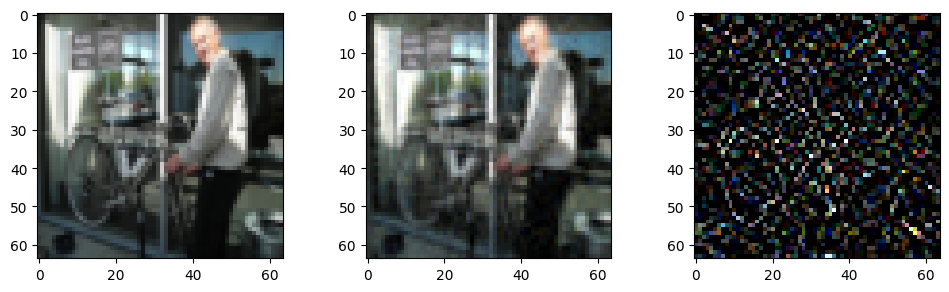

19
[np.float32(0.9890968), np.float32(0.9881184), np.float32(0.9876699)]


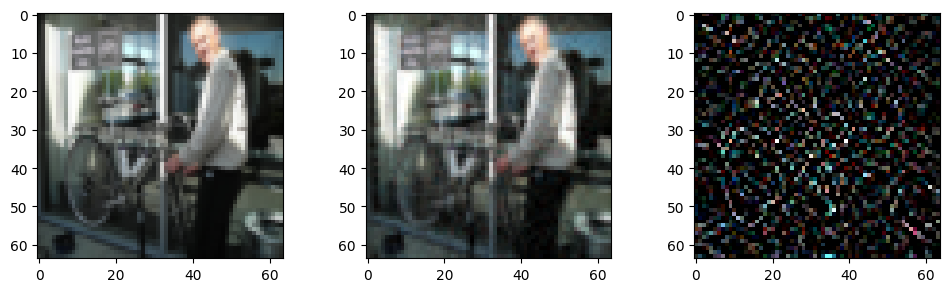

20
[np.float32(0.9905044), np.float32(0.98975176), np.float32(0.98931384)]


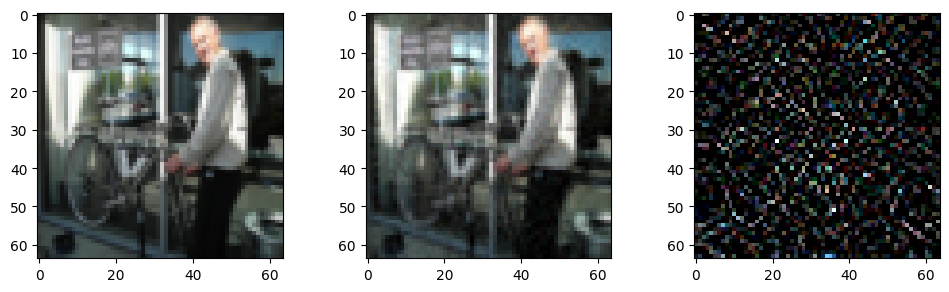

21
[np.float32(0.991711), np.float32(0.99096864), np.float32(0.9905077)]


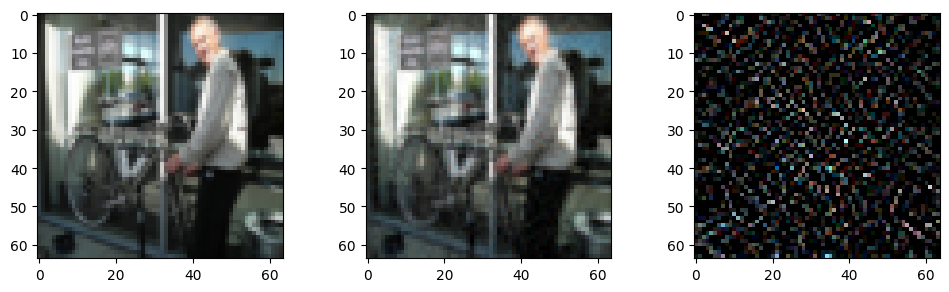

In [16]:
final_size = (64,64)
PCA_COMPONENTS = [18,19,20,21]
pca_image_files = glob(TRAIN_IMAGES_PATH+"*.jpg")[500:501]
pca_image_dataset = [load_image(image_file,size=final_size) for image_file in pca_image_files]

for n_components in PCA_COMPONENTS:
    print(n_components)
    recon_error = []
    var_channels = []

    for img in pca_image_dataset:
        plot_pca(img,n_components=n_components)

[np.float32(0.9925797), np.float32(0.9935918), np.float32(0.9923688)]


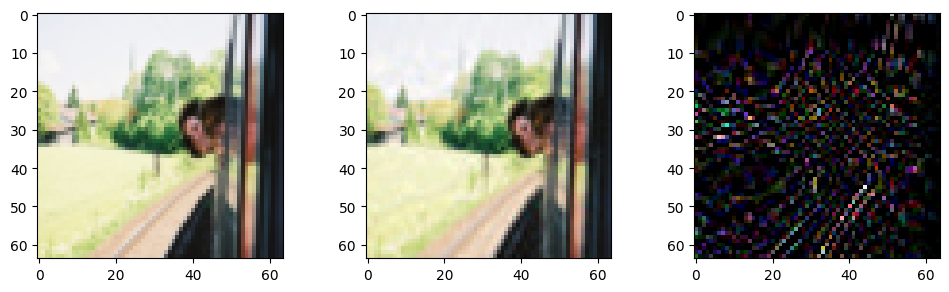

[np.float32(0.99572664), np.float32(0.99756694), np.float32(0.9788831)]


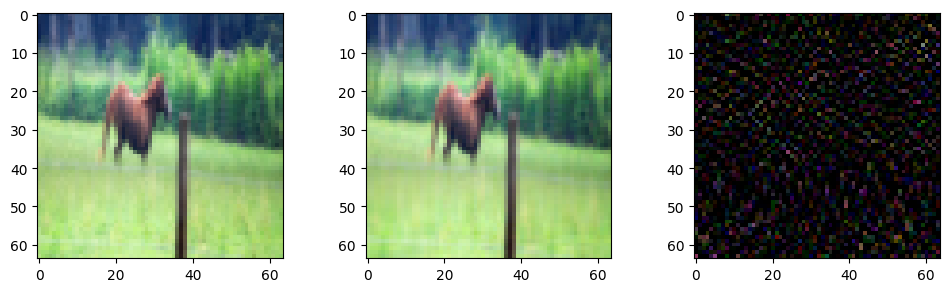

[np.float32(0.9915965), np.float32(0.9933068), np.float32(0.9929404)]


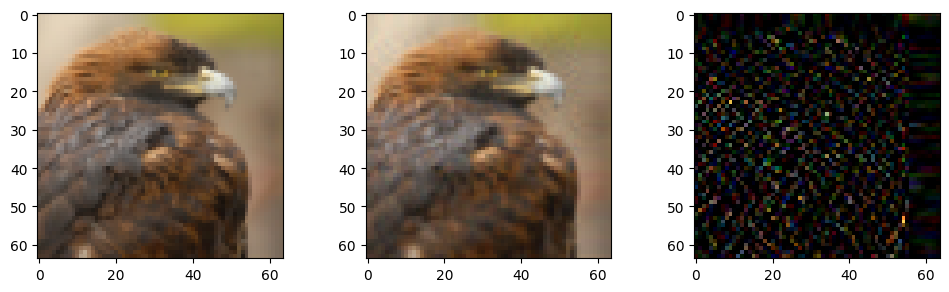

[np.float32(0.9945591), np.float32(0.9937931), np.float32(0.99685955)]


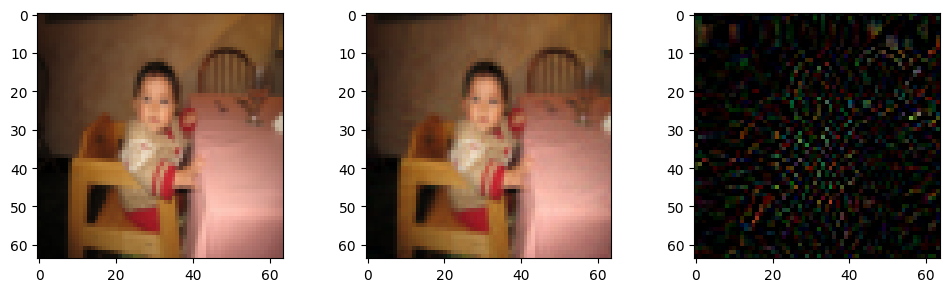

[np.float32(0.9990975), np.float32(0.9983932), np.float32(0.9982233)]


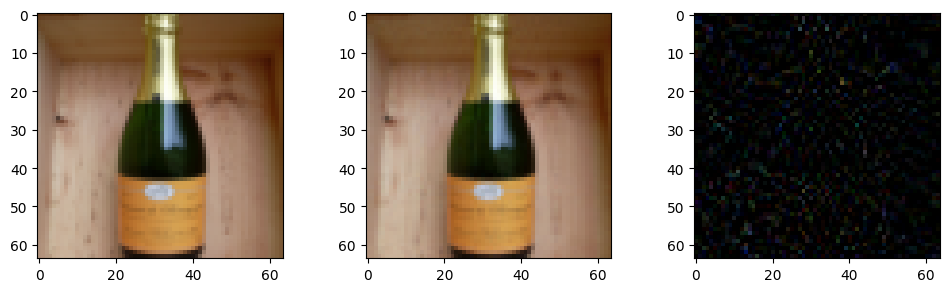

[np.float32(0.99116737), np.float32(0.99149185), np.float32(0.99241763)]


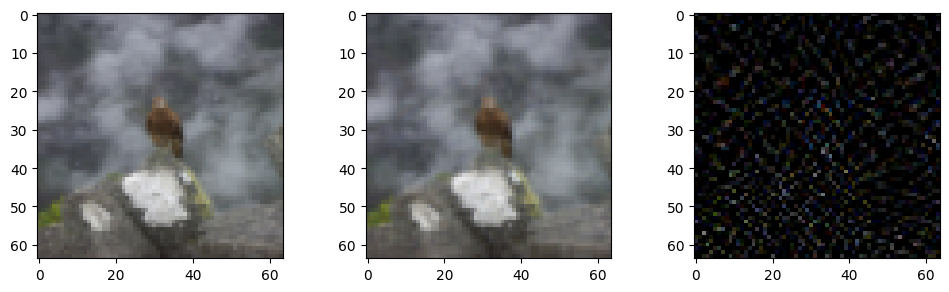

[np.float32(0.9928926), np.float32(0.9946441), np.float32(0.9963024)]


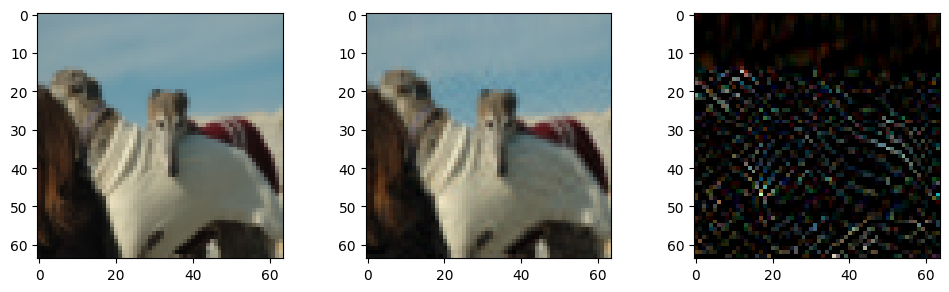

[np.float32(0.99449474), np.float32(0.99539536), np.float32(0.99564826)]


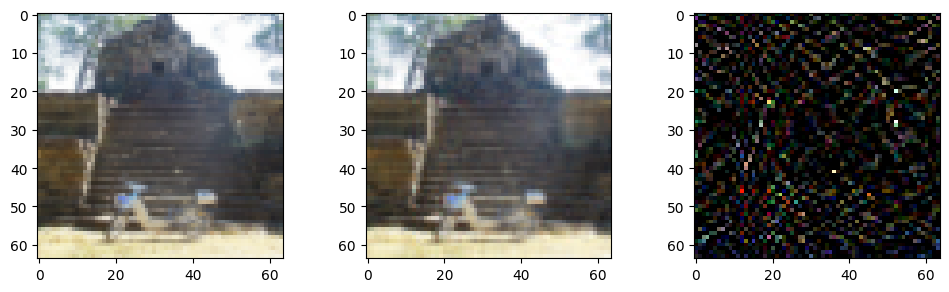

[np.float32(0.99184185), np.float32(0.9912857), np.float32(0.9921075)]


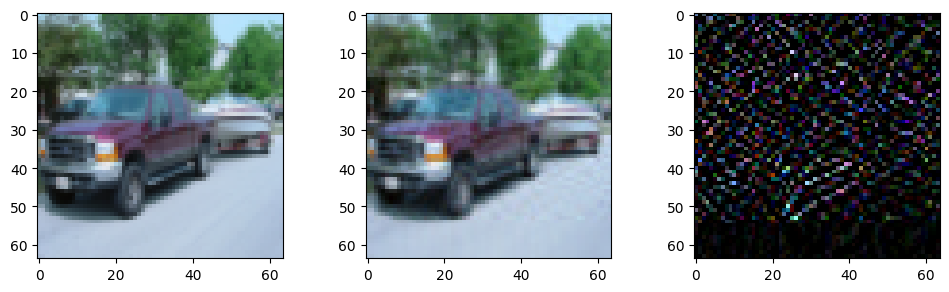

[np.float32(0.99899095), np.float32(0.99982303), np.float32(0.99894994)]


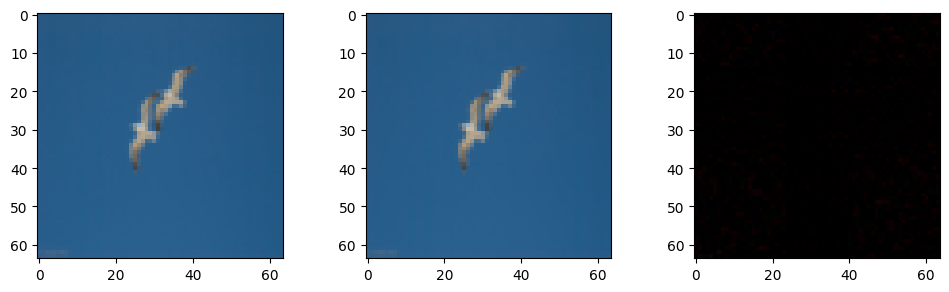

[np.float32(0.9903341), np.float32(0.9824961), np.float32(0.99097574)]


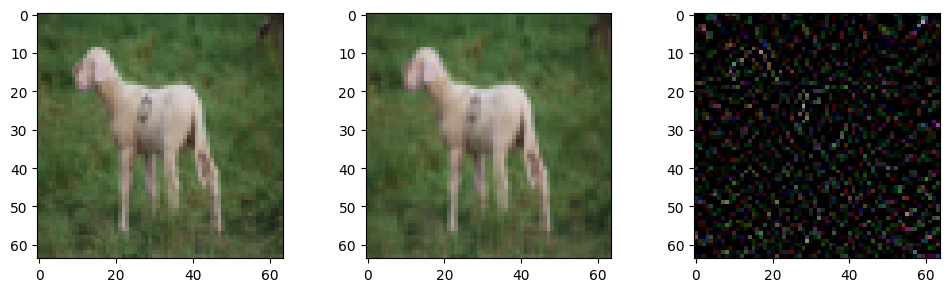

[np.float32(0.9908703), np.float32(0.9921391), np.float32(0.9939656)]


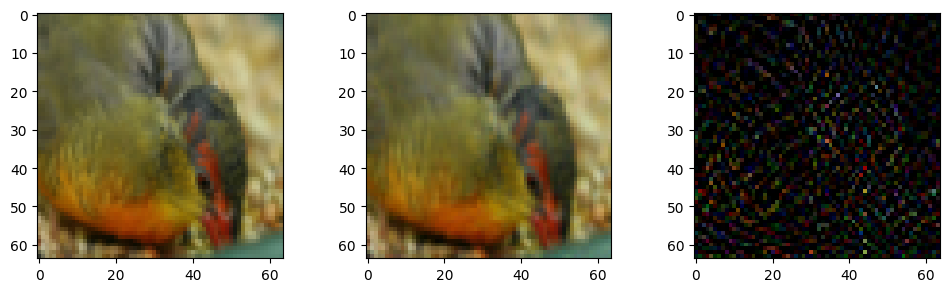

[np.float32(0.99234277), np.float32(0.99016446), np.float32(0.99189454)]


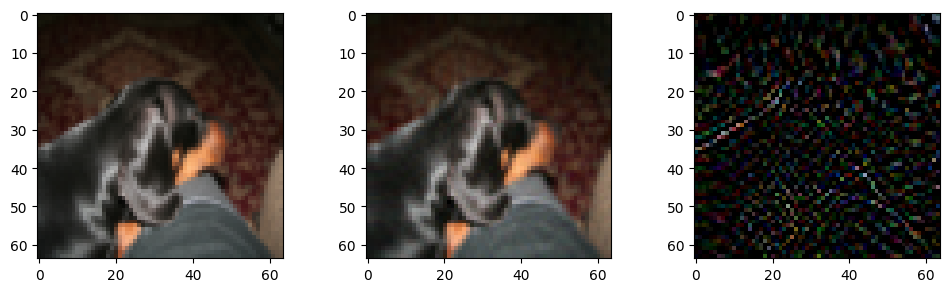

[np.float32(0.9832723), np.float32(0.98092717), np.float32(0.9823074)]


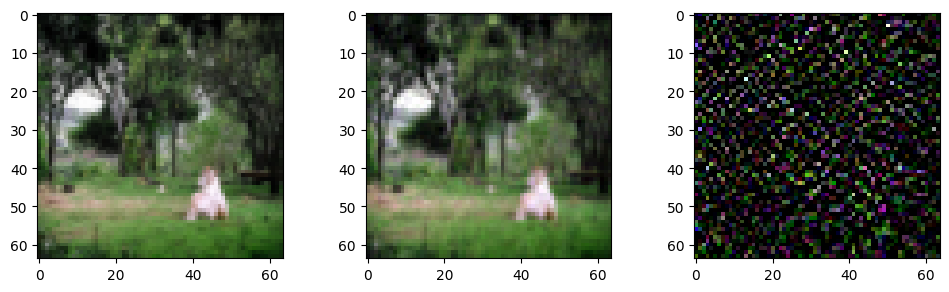

[np.float32(0.9829799), np.float32(0.9822628), np.float32(0.9823106)]


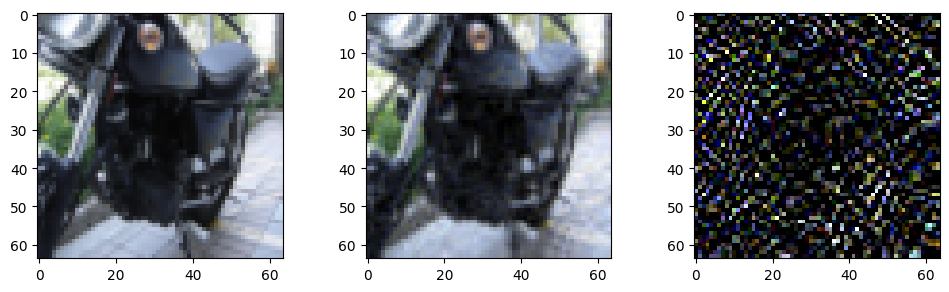

[np.float32(0.99231404), np.float32(0.9917709), np.float32(0.98725307)]


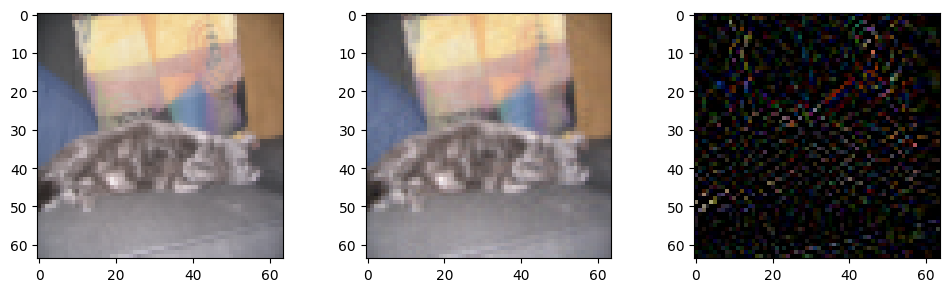

[np.float32(0.9932298), np.float32(0.9956547), np.float32(0.99378204)]


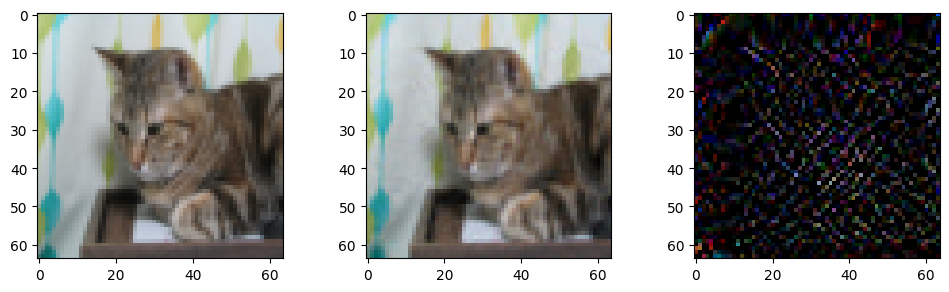

[np.float32(0.9933794), np.float32(0.9947303), np.float32(0.99235153)]


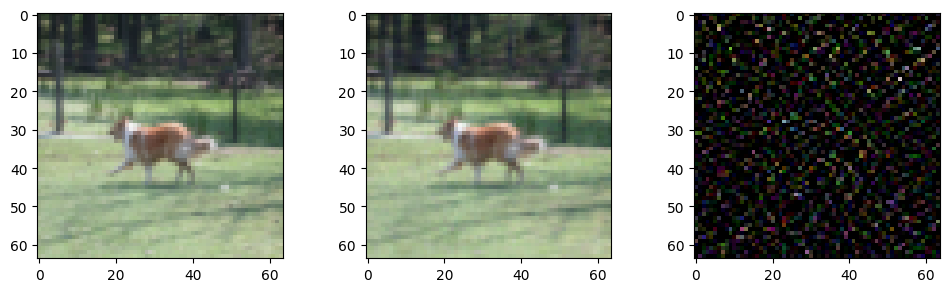

[np.float32(0.9995351), np.float32(0.99964845), np.float32(0.99968505)]


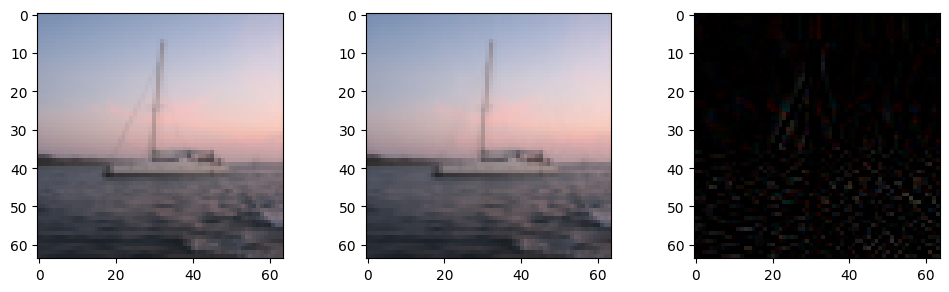

[np.float32(0.9866774), np.float32(0.98320246), np.float32(0.9799427)]


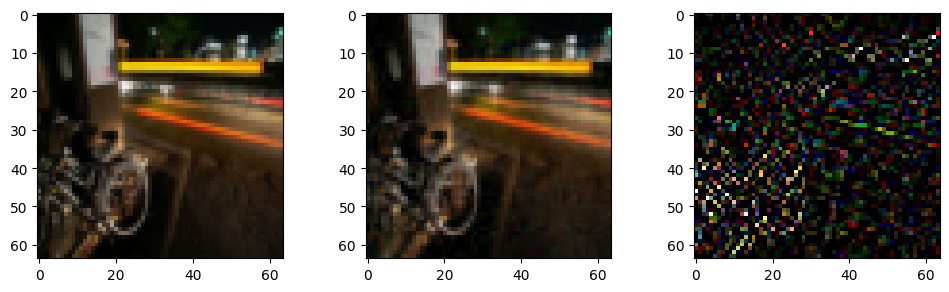

In [ ]:
final_size = (64,64)
PCA_COMPONENTS = [19] ## as 19 was the maximum of mode of k_channels for all 3 channels
pca_image_files = glob(TRAIN_IMAGES_PATH+"*.jpg")[100:120]
pca_image_dataset = [load_image(image_file,size=final_size) for image_file in pca_image_files]

for n_components in PCA_COMPONENTS:
    recon_error = []
    var_channels = []

    for img in pca_image_dataset:
        plot_pca(img,n_components=n_components)

# Multi-label Image classification

In [5]:
from classification.model import *

In [ ]:
# FOLDER_PATH = "/kaggle/input/competitions/mlds-2026-assignment-2/Dataset/"
'''
change FOLDER_PATH accordingly
'''
FOLDER_PATH = "../"
TRAIN_IMAGES_PATH = FOLDER_PATH + "train/images/"
TEST_IMAGES_PATH = FOLDER_PATH + "test/images/"
TRAIN_LABELS_PATH = FOLDER_PATH + "train/labels.csv"

## Dataset

In [ ]:
labels = pd.read_csv(TRAIN_LABELS_PATH)
classes = labels.columns[1:].tolist()
print(classes)
labels.head()

['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


,image_id,aeroplane,bicycle,bird,boat,bottle,bus,car,cat,chair,...,diningtable,dog,horse,motorbike,person,pottedplant,sheep,sofa,train,tvmonitor
0,img_00001,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,img_00002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,img_00003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,img_00004,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,img_00006,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
training_path =   FOLDER_PATH + "train/"

dataset = MultiLabelDataset(training_path, transform=cls_preprocess)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False,num_workers=2)

## Models Training

In [ ]:
def get_predicted_classes(pred_dict, threshold=0.5):
    classes = [cls for cls, prob in pred_dict.items() if prob >= threshold]
    return " ".join(classes) if classes else "background"

In [ ]:
weight_dir = FOLDER_PATH + '25886_Kritika_Gupta_Assignment_2/classification/weights'
cls_model = ClassificationModel(weights_dir = weight_dir)

Using ImageNet pretrained backbone + random classifier


c:\Program Files\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
cls_model.train(train_loader, val_loader, num_epochs=20,lr=7e-5)

Starting training...


Epoch 1 Training: 100%|██████████| 110/110 [00:33<00:00,  3.24it/s]


[TRAINING Epoch 1] Train Loss: 0.1183


Validating: 100%|██████████| 28/28 [00:16<00:00,  1.68it/s]


[VALIDATION] Loss: 0.1032 | Accuracy: 0.9636 | F1 Score: 0.8416


...

[VALIDATION] Loss: 0.0964 | Accuracy: 0.9664 | F1 Score: 0.8558


Epoch 10 Training: 100%|██████████| 110/110 [00:34<00:00,  3.23it/s]


[TRAINING Epoch 10] Train Loss: 0.0932


Validating: 100%|██████████| 28/28 [00:18<00:00,  1.55it/s]

[VALIDATION] Loss: 0.0945 | Accuracy: 0.9669 | F1 Score: 0.8611


In [ ]:
cls_model.validate(train_loader,threshold=0.5),cls_model.validate(val_loader,threshold=0.5)

Validating: 100%|██████████| 110/110 [00:28<00:00,  3.90it/s]


[VALIDATION] Loss: 0.0653 | Accuracy: 0.9769 | F1 Score: 0.9073


Validating: 100%|██████████| 28/28 [00:16<00:00,  1.65it/s]

[VALIDATION] Loss: 0.0945 | Accuracy: 0.9669 | F1 Score: 0.8611


((0.0653439136729999, 0.9769034090909091),
 (0.09454743856830257, 0.9669318181818182))

In [ ]:
'''
Running this will overwrite the existing model weights.
'''
# cls_model.save_model(save_path = 'cls_model_20epochs_7e-5lr.pth')

# Segmentation

In [4]:
from segmentation.model import *

In [ ]:
# FOLDER_PATH = "/kaggle/input/competitions/mlds-2026-assignment-2/Dataset/"
'''
change FOLDER_PATH accordingly
'''
FOLDER_PATH = "../"
TRAIN_IMAGES_PATH = FOLDER_PATH + "train/images/"
TEST_IMAGES_PATH = FOLDER_PATH + "test/images/"
TRAIN_MASKS_PATH = FOLDER_PATH + "train/segmentation_masks/"

## Dataset

In [ ]:
training_path =   FOLDER_PATH + "train/"

dataset = SegmentationDataset(training_path, transform=preprocess_seg)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False,num_workers=2)

## Training

#### Model A: With no skip connections

In [ ]:
weight_dir = FOLDER_PATH + '25886_Kritika_Gupta_Assignment_2/segmentation/weights'
seg_model_no_skip = SegmentationModel(weights_dir = weight_dir,use_skipconnections=False)

Using ImageNet pretrained encoder + random decoder


c:\Program Files\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
seg_model_no_skip.train(train_loader, val_loader, num_epochs=10,lr=1e-4)

In [ ]:
seg_model_no_skip.validate(train_loader),seg_model_no_skip.validate(val_loader)

In [ ]:
## uncomment to overwrite the model
# seg_model_no_skip.save_model(save_path = 'model_seg_no_skip_lr_1_4.pth')

#### Model B: With skip connections

In [ ]:
weight_dir = FOLDER_PATH + '25886_Kritika_Gupta_Assignment_2/segmentation/weights'
seg_model_skip = SegmentationModel(weights_dir = weight_dir,use_skipconnections=True)

Using ImageNet pretrained encoder + random decoder


In [8]:
seg_model_skip.train(train_loader, val_loader, num_epochs=10,lr=1e-4)

In [9]:
seg_model_skip.validate(train_loader),seg_model_skip.validate(val_loader)

In [ ]:
## uncomment to overwrite the model
# seg_model_skip.save_model(save_path = 'model_seg_skip_10epochs_1e-4lr.pth')

# Generate CSV


In [2]:
import numpy as np

def mask_to_rle(mask: np.ndarray) -> str:
    """
    Convert a 2D segmentation mask to RLE string.
    mask: (H, W) numpy array with class indices (0=bg, 1-20=class, 255=ignore)
    """
    flat = mask.flatten()  # row-major order
    # Find runs of non-zero pixels
    starts = []
    lengths = []
    values = []
    i = 0
    while i < len(flat):
        if flat[i] != 0:
            start = i
            val = flat[i]
            while i < len(flat) and flat[i] == val:
                i += 1
            starts.append(start)
            lengths.append(i - start)
            values.append(val)
        else:
            i += 1
    # Format: start1 length1 value1 start2 length2 value2 ...
    parts = []
    for s, l, v in zip(starts, lengths, values):
        parts.extend([str(s), str(l), str(v)])
    return " ".join(parts) if parts else "0 0 0"


def rle_to_mask(rle_string: str, height: int, width: int) -> np.ndarray:
    """
    Decode RLE string back to a 2D segmentation mask.
    """
    mask = np.zeros(height * width, dtype=np.uint8)
    parts = list(map(int, rle_string.split()))
    for i in range(0, len(parts), 3):
        start, length, value = parts[i], parts[i+1], parts[i+2]
        mask[start:start+length] = value
    return mask.reshape(height, width)


In [7]:
TEST_PATH = "../test/images/"

cls_model_test = ClassificationModel(weights_dir="classification/weights",model_weights="cls_model_20epochs_7e-5lr.pth") ## keep 20 epoch one
seg_model_test = SegmentationModel(weights_dir="segmentation/weights",model_weights="model_seg_skip_10epochs_1e-4lr.pth")

c:\Program Files\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded trained weights
Loaded trained segmentation weights


In [8]:
rows = []

for file in tqdm(os.listdir(TEST_PATH),desc='Testing'):
    if not file.endswith(".jpg"):
        continue

    image_id = file.replace(".jpg", "")
    img = np.array(Image.open(os.path.join(TEST_PATH, file)).convert("RGB"))

    ## classification
    pred_dict = cls_model_test.predict(img)
    classes = [k for k,v in pred_dict.items() if v >= 0.5]
    classification = " ".join(classes) if classes else "background"

    ## segmentation
    mask = seg_model_test.predict(img)   # (H,W)
    rle = mask_to_rle(mask)

    rows.append([image_id, classification, rle])

df = pd.DataFrame(rows, columns=["image_id","classification","segmentation_rle"])
df.to_csv("submission.csv", index=False)

Testing: 100%|██████████| 713/713 [02:25<00:00,  4.91it/s]


In [9]:
df

,image_id,classification,segmentation_rle
0,img_00005,bicycle person,69712 7 15 70212 7 15 70705 20 15 71203 25 15 ...
1,img_00009,person,52855 20 15 53355 20 15 53850 32 15 54350 32 1...
2,img_00010,person,68766 15 7 69266 15 7 69761 27 7 70257 38 7 70...
3,img_00014,cat,13319 16 8 13819 16 8 14308 34 8 14808 34 8 15...
4,img_00015,person,28139 10 15 28457 10 15 28772 16 15 29090 16 1...
...,...,...,...
708,img_02896,cat,10266 11 8 10319 23 8 10766 11 8 10819 23 8 11...
709,img_02900,train,42373 6 19 42859 41 19 43359 41 19 43853 51 19...
710,img_02910,bird,59306 9 3 59804 15 3 60304 15 3 60801 23 3 613...
711,img_02911,boat,0 0 0
